# Machine Learning — Predicción de decisiones perceptuales
## TFG: Analysis of brain patterns using machine learning algorithms
### Martina Napoli Crespo

---

**Objetivos de este análisis:**
1. Predecir si un participant **cambiará su decisión** (`switch`) o la mantendrá — directamente ligado a la Hipótesis 5 del TFG.
2. Predecir **cuál será la decisión** del participant (`deci`: cardinal vs diagonal) — análisis complementario.
3. Cuantificar la **contribución relativa** de evidencia sensorial, historia de decisiones (CB) y metacognición.
4. Estudiar cómo el rendimiento varía según la **cantidad de historia disponible** (nrep).
5. Explorar **diferencias individuales** en predictibilidad y su relación con métricas conductuales de CB.

**Nota metodológica clave — GroupKFold:**  
Toda la validación cruzada usa `GroupKFold` con `grupos = participants`. Esto garantiza que en cada fold el modelo se entrena y testa en **participants completamente distintos**, evitando la filtración de información (*data leakage*) que ocurriría si trials del mismo participant apareciesen en train y test simultáneamente. Es el estándar correcto para datos con estructura jerárquica (trials anidados en participants).


---
## Bloque 0 — Librerías y configuración

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (GroupKFold, cross_validate,
                                     cross_val_score, LeaveOneGroupOut)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, roc_auc_score

sns.set(font_scale=1.2, style='ticks')
plt.rcParams['figure.dpi'] = 100
SEED = 42

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


---
## Bloque 1 — Carga de datos y preprocesamiento

In [43]:
# ── Celda 1: Cargar datos ────────────────────────────────────────────────────
data_path = '/Users/martu/Documents/TFG_MARTINA/dataset/CJ_EEG.csv'  # ajusta si es necesario
all_df = pd.read_csv(data_path)
print(f'Dataset cargado: {all_df.shape[0]} filas, {all_df.shape[1]} columnas')
print(f'Participantes: {all_df["subj"].nunique()}')
print(f'Columnas: {list(all_df.columns)}')

Dataset cargado: 6600 filas, 36 columnas
Participantes: 25
Columnas: ['exp_ID', 'npar', 'subj', 'nblock', 'ntrial', 'nrep', 'cond-1', 'trial_type', 'rDV', 'deci-3', 'deci-2', 'deci-1', 'cond', 'deci', 'DV', 'resp', 'corr-1', 'r_map', 'correct', 'confi', 'RT', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'o1', 'o2', 'o3', 'o4', 'o5', 'o6', 'metad', 'metad_3%', 'metad_97%']


In [44]:
# ── Celda 2: Preprocesamiento ────────────────────────────────────────────────
df = all_df.copy()

# Recodificaciones
df['cond']    = df['cond'].replace({-1: 0})
df['correct'] = df['correct'].replace({-1: 0})
df['switch']  = (df['deci'] != df['deci-1']).astype(int)

# Previous confidence
df = df.sort_values(['subj', 'nblock', 'ntrial', 'nrep']).reset_index(drop=True)
df['confi-1']   = df.groupby(['subj', 'nblock', 'ntrial'])['confi'].shift(1)
df['correct-1'] = df['corr-1']

# Variables derivadas
df['is_repeat'] = (df['trial_type'] == 'repeat').astype(int)
df['deci1_c']   = df['deci-1'] - 0.5  # centrado

# Estandarización por participant (evita que diferencias de escala entre
# participants contaminen las features del modelo)
df['rDV_z']   = df.groupby('subj')['rDV'].transform(
    lambda x: (x - x.mean()) / x.std())
df['RT_z']    = df.groupby('subj')['RT'].transform(
    lambda x: (x - x.mean()) / x.std())
df['confi_z'] = df.groupby('subj')['confi'].transform(
    lambda x: (x - x.mean()) / x.std())
df['confi1_z'] = df.groupby('subj')['confi-1'].transform(
    lambda x: (x - x.mean()) / x.std())

# ── Filtro RT (igual que análisis conductual) ────────────────────────────────
def RT_filter(x, sd=4):
    return x[x['RT'] < x['RT'].mean() + sd * x['RT'].std()]

df = df.groupby('npar', group_keys=False).apply(RT_filter, sd=4).reset_index(drop=True)

print(f'Trials tras filtro RT: {len(df)}')
print(f'Participantes: {df["subj"].nunique()}')

Trials tras filtro RT: 6537
Participantes: 25


In [45]:
# ── Celda 3: Metacognitive efficiency por participant ───────────────────────
# Calculamos meta-d' efficiency (Mratio = metad/dprime) por participant
# Usamos solo nrep=0 para no contaminar con el CB

df0 = df[df['nrep'] == 0].copy()

def calc_dprime(x):
    hits   = ((x['deci'] == 1) & (x['cond'] == 1)).sum()
    signal = (x['cond'] == 1).sum()
    fa     = ((x['deci'] == 1) & (x['cond'] == 0)).sum()
    noise  = (x['cond'] == 0).sum()
    hr  = (hits + 0.5) / (signal + 1)
    far = (fa   + 0.5) / (noise  + 1)
    return pd.Series({'dprime': norm.ppf(hr) - norm.ppf(far)})

dprime_df  = df0.groupby('subj').apply(calc_dprime, include_groups=False).reset_index()
metad_subj = df.groupby('subj')['metad'].first().reset_index()
eff_df     = metad_subj.merge(dprime_df, on='subj')
eff_df['metad_eff'] = eff_df['metad'] / eff_df['dprime']

# Unimos al dataframe principal
df = df.merge(eff_df[['subj', 'metad_eff']], on='subj', how='left')

print('Metacognitive efficiency calculada ✓')
print(eff_df[['subj', 'dprime', 'metad', 'metad_eff']].round(3))

Metacognitive efficiency calculada ✓
   subj  dprime  metad  metad_eff
0   S03   1.397  0.556      0.398
1   s01   1.123  0.086      0.077
2   s04   1.358  0.591      0.435
3   s05   1.477  0.558      0.378
4   s07   1.118  0.596      0.533
5   s08   1.039  0.727      0.700
6   s09   1.049  1.107      1.055
7   s10   1.026  1.217      1.187
8   s11   0.882  0.509      0.577
9   s12   1.306  0.487      0.373
10  s13   1.185  0.794      0.670
11  s14   1.084  0.586      0.541
12  s15   1.253  0.913      0.728
13  s16   1.125  0.296      0.263
14  s17   1.238  1.106      0.894
15  s18   1.258  0.195      0.155
16  s19   1.191  0.578      0.485
17  s20   1.362  0.596      0.437
18  s21   1.168  0.359      0.307
19  s22   1.104  1.226      1.111
20  s23   1.395  0.444      0.318
21  s24   1.526    NaN        NaN
22  s25   1.470  0.906      0.616
23  s26   1.199  0.248      0.207
24  s27   1.488  0.400      0.269


---
## Bloque 2 — Definición de features y targets

Las features se organizan en **4 grupos teóricos** que mapean directamente a las hipótesis del TFG:

| Grupo | Features | Hipótesis relacionada |
|---|---|---|
| **Sensorial** | rDV_z, d1–d6 | H1: la evidencia sensorial guía las decisiones |
| **History / CB** | deci-1, deci-2, deci-3, corr-1, confi1_z | H2–H3: el CB y la confidence sesgan la integración |
| **Behavioural** | RT_z, nrep, is_repeat | H1: variables de tarea |
| **Metacognición** | metad_eff | H3: la eficiencia metacognitiva modula el CB |

In [46]:
# ── Celda 4: Definición de features ─────────────────────────────────────────

# Grupos de features (estructura teórica del TFG)
sensory_features  = ['rDV_z', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6']
history_features  = ['deci-1', 'deci-2', 'deci-3', 'corr-1', 'confi1_z']
behav_features    = ['RT_z', 'nrep', 'is_repeat']
meta_features     = ['metad_eff']

all_features = sensory_features + history_features + behav_features + meta_features

# ── Targets ──────────────────────────────────────────────────────────────────
# TARGET 1: switch — ¿cambia la decisión respecto a la anterior?
#   Solo tiene sentido en nrep > 0 (necesitamos decisión prev. decision)
#   Es el target principal: alineado con la Hipótesis 5 del TFG
#
# TARGET 2: deci — ¿cardinal (0) o diagonal (1)?
#   Usamos todos los nrep
#   Análisis complementario

print('Features por grupo:')
print(f'  Sensoriales  ({len(sensory_features)}): {sensory_features}')
print(f'  Historia/CB  ({len(history_features)}): {history_features}')
print(f'  Behaviourales ({len(behav_features)}): {behav_features}')
print(f'  Metacognición({len(meta_features)}): {meta_features}')
print(f'  TOTAL: {len(all_features)} features')

Features por grupo:
  Sensoriales  (7): ['rDV_z', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6']
  Historia/CB  (5): ['deci-1', 'deci-2', 'deci-3', 'corr-1', 'confi1_z']
  Behaviourales (3): ['RT_z', 'nrep', 'is_repeat']
  Metacognición(1): ['metad_eff']
  TOTAL: 16 features


In [47]:
# ── Celda 5: Preparar datasets para cada target ──────────────────────────────

# ── Dataset para TARGET 1: switch (solo nrep > 0) ────────────────────────────
df_switch = df[df['nrep'] > 0].dropna(
    subset=all_features + ['switch', 'subj']
).reset_index(drop=True)

X_sw    = df_switch[all_features].values
y_sw    = df_switch['switch'].values
groups_sw = df_switch['npar'].values

print('── TARGET 1: switch ────────────────────────────────────────')
print(f'Trials: {len(df_switch)} | Participantes: {df_switch["subj"].nunique()}')
n_sw   = (y_sw == 0).sum()
n_rep  = (y_sw == 1).sum()
print(f'Mantiene (0): {n_sw} ({n_sw/len(y_sw)*100:.1f}%)  |  Cambia (1): {n_rep} ({n_rep/len(y_sw)*100:.1f}%)')

# ── Dataset para TARGET 2: deci (todos los nrep) ─────────────────────────────
# Para deci excluimos deci-1 de las features en nrep=0 (no existe decisión prev. decision)
# Usamos todos los nrep con NaN en historia rellenados a 0.5 (neutral)
df_deci = df.dropna(subset=sensory_features + behav_features + meta_features + ['deci', 'subj']).copy()
for col in history_features:
    if col in df_deci.columns:
        df_deci[col] = df_deci[col].fillna(0)  # neutral para nrep=0

X_dc      = df_deci[all_features].values
y_dc      = df_deci['deci'].values
groups_dc = df_deci['npar'].values

print('\n── TARGET 2: deci ──────────────────────────────────────────')
print(f'Trials: {len(df_deci)} | Participantes: {df_deci["subj"].nunique()}')
n_card = (y_dc == 0).sum()
n_diag = (y_dc == 1).sum()
print(f'Cardinal (0): {n_card} ({n_card/len(y_dc)*100:.1f}%)  |  Diagonal (1): {n_diag} ({n_diag/len(y_dc)*100:.1f}%)')

── TARGET 1: switch ────────────────────────────────────────
Trials: 4195 | Participantes: 24
Mantiene (0): 3592 (85.6%)  |  Cambia (1): 603 (14.4%)

── TARGET 2: deci ──────────────────────────────────────────
Trials: 6274 | Participantes: 24
Cardinal (0): 2766 (44.1%)  |  Diagonal (1): 3508 (55.9%)


---
## Bloque 3 — Modelos y validación con GroupKFold

**¿Por qué GroupKFold?**  
Los datos tienen estructura jerárquica: trials anidados dentro de participants. Si en cada fold el modelo ve trials del mismo participant en train y en test, el rendimiento estimado está inflado porque el modelo "conoce" los patrones individuales de ese sujeto. Con GroupKFold, cada fold entrena en un subconjunto de participants y testa en participants completamente distintos — esto evalúa la **generalización real** del modelo a nuevos sujetos, que es la pregunta científicamente relevante.

In [48]:
# ── Celda 6: Definición de modelos ───────────────────────────────────────────

# GroupKFold: cada fold = subconjunto de participants distintos
# N_FOLDS ≤ n_participants; usamos 5 como compromiso varianza/coste
N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',  # compensa posible desbalance
            max_iter=1000,
            C=1.0,
            random_state=SEED
        ))
    ]),
    'SVM (lineal)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='linear',
            class_weight='balanced',
            probability=True,
            C=1.0,
            random_state=SEED
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            max_depth=8,           # regularizado para evitar overfitting
            min_samples_leaf=20,
            class_weight='balanced',
            random_state=SEED,
            n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,    # learning rate bajo = menos overfitting
            max_depth=3,
            subsample=0.8,
            random_state=SEED
        ))
    ])
}

scoring = {
    'accuracy': 'accuracy',
    'auc'     : 'roc_auc',
    'f1'      : 'f1'
}

print(f'Modelos definidos: {list(models.keys())}')
print(f'Validación: GroupKFold (k={N_FOLDS}, grupos=participants)')

Modelos definidos: ['Logistic Regression', 'SVM (lineal)', 'Random Forest', 'Gradient Boosting']
Validación: GroupKFold (k=5, grupos=participants)


In [49]:
# ── Celda 7: Entrenamiento — TARGET 1: switch ────────────────────────────────
print('Entrenando modelos para TARGET: switch (¿cambia la decisión?)')
print('=' * 60)

results_sw = {}

for name, pipeline in models.items():
    print(f'  {name}...', end=' ')
    cv = cross_validate(
        pipeline, X_sw, y_sw,
        groups=groups_sw,           # <- clave: GroupKFold usa esto
        cv=gkf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    results_sw[name] = {
        'acc_test' : cv['test_accuracy'],
        'acc_train': cv['train_accuracy'],
        'auc_test' : cv['test_auc'],
        'f1_test'  : cv['test_f1'],
    }
    acc  = cv['test_accuracy'].mean()
    auc  = cv['test_auc'].mean()
    over = cv['train_accuracy'].mean() - acc
    print(f'Acc={acc:.3f}  AUC={auc:.3f}  Overfit={over:.3f}')

print('\nEntrenamiento completado ✓')

Entrenando modelos para TARGET: switch (¿cambia la decisión?)
  Logistic Regression... Acc=0.677  AUC=0.735  Overfit=0.010
  SVM (lineal)... Acc=0.678  AUC=0.731  Overfit=0.010
  Random Forest... Acc=0.729  AUC=0.745  Overfit=0.082
  Gradient Boosting... Acc=0.841  AUC=0.737  Overfit=0.062

Entrenamiento completado ✓


In [50]:
# ── Celda 8: Entrenamiento — TARGET 2: deci ──────────────────────────────────
print('Entrenando modelos para TARGET: deci (cardinal vs diagonal)')
print('=' * 60)

results_dc = {}

for name, pipeline in models.items():
    print(f'  {name}...', end=' ')
    cv = cross_validate(
        pipeline, X_dc, y_dc,
        groups=groups_dc,
        cv=gkf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    results_dc[name] = {
        'acc_test' : cv['test_accuracy'],
        'acc_train': cv['train_accuracy'],
        'auc_test' : cv['test_auc'],
        'f1_test'  : cv['test_f1'],
    }
    acc  = cv['test_accuracy'].mean()
    auc  = cv['test_auc'].mean()
    over = cv['train_accuracy'].mean() - acc
    print(f'Acc={acc:.3f}  AUC={auc:.3f}  Overfit={over:.3f}')

print('\nEntrenamiento completado ✓')

Entrenando modelos para TARGET: deci (cardinal vs diagonal)
  Logistic Regression... Acc=0.784  AUC=0.861  Overfit=0.005
  SVM (lineal)... Acc=0.763  AUC=0.852  Overfit=0.005
  Random Forest... Acc=0.811  AUC=0.885  Overfit=0.032
  Gradient Boosting... Acc=0.803  AUC=0.879  Overfit=0.052

Entrenamiento completado ✓


In [51]:
# ── Celda 9: Tabla resumen comparativa ──────────────────────────────────────

def make_results_table(results_dict, label):
    rows = []
    for name, res in results_dict.items():
        rows.append({
            'Modelo'    : name,
            'Acc'       : f"{res['acc_test'].mean():.3f} ± {res['acc_test'].std():.3f}",
            'AUC-ROC'   : f"{res['auc_test'].mean():.3f} ± {res['auc_test'].std():.3f}",
            'F1'        : f"{res['f1_test'].mean():.3f} ± {res['f1_test'].std():.3f}",
            'Train Acc' : f"{res['acc_train'].mean():.3f}",
            'Overfit'   : f"{res['acc_train'].mean() - res['acc_test'].mean():.3f}"
        })
    df_res = pd.DataFrame(rows)
    print(f'\n── Target: {label} ──────────────────────────────────────────')
    print(df_res.to_string(index=False))
    return df_res

table_sw = make_results_table(results_sw, 'switch (¿cambia decisión?)')
table_dc = make_results_table(results_dc, 'deci (cardinal vs diagonal)')


── Target: switch (¿cambia decisión?) ──────────────────────────────────────────
             Modelo           Acc       AUC-ROC            F1 Train Acc Overfit
Logistic Regression 0.677 ± 0.018 0.735 ± 0.014 0.368 ± 0.063     0.687   0.010
       SVM (lineal) 0.678 ± 0.027 0.731 ± 0.011 0.375 ± 0.069     0.688   0.010
      Random Forest 0.729 ± 0.030 0.745 ± 0.012 0.367 ± 0.063     0.811   0.082
  Gradient Boosting 0.841 ± 0.027 0.737 ± 0.013 0.132 ± 0.033     0.903   0.062

── Target: deci (cardinal vs diagonal) ──────────────────────────────────────────
             Modelo           Acc       AUC-ROC            F1 Train Acc Overfit
Logistic Regression 0.784 ± 0.015 0.861 ± 0.010 0.799 ± 0.022     0.789   0.005
       SVM (lineal) 0.763 ± 0.024 0.852 ± 0.015 0.785 ± 0.029     0.768   0.005
      Random Forest 0.811 ± 0.011 0.885 ± 0.011 0.826 ± 0.016     0.843   0.032
  Gradient Boosting 0.803 ± 0.009 0.879 ± 0.013 0.823 ± 0.017     0.855   0.052


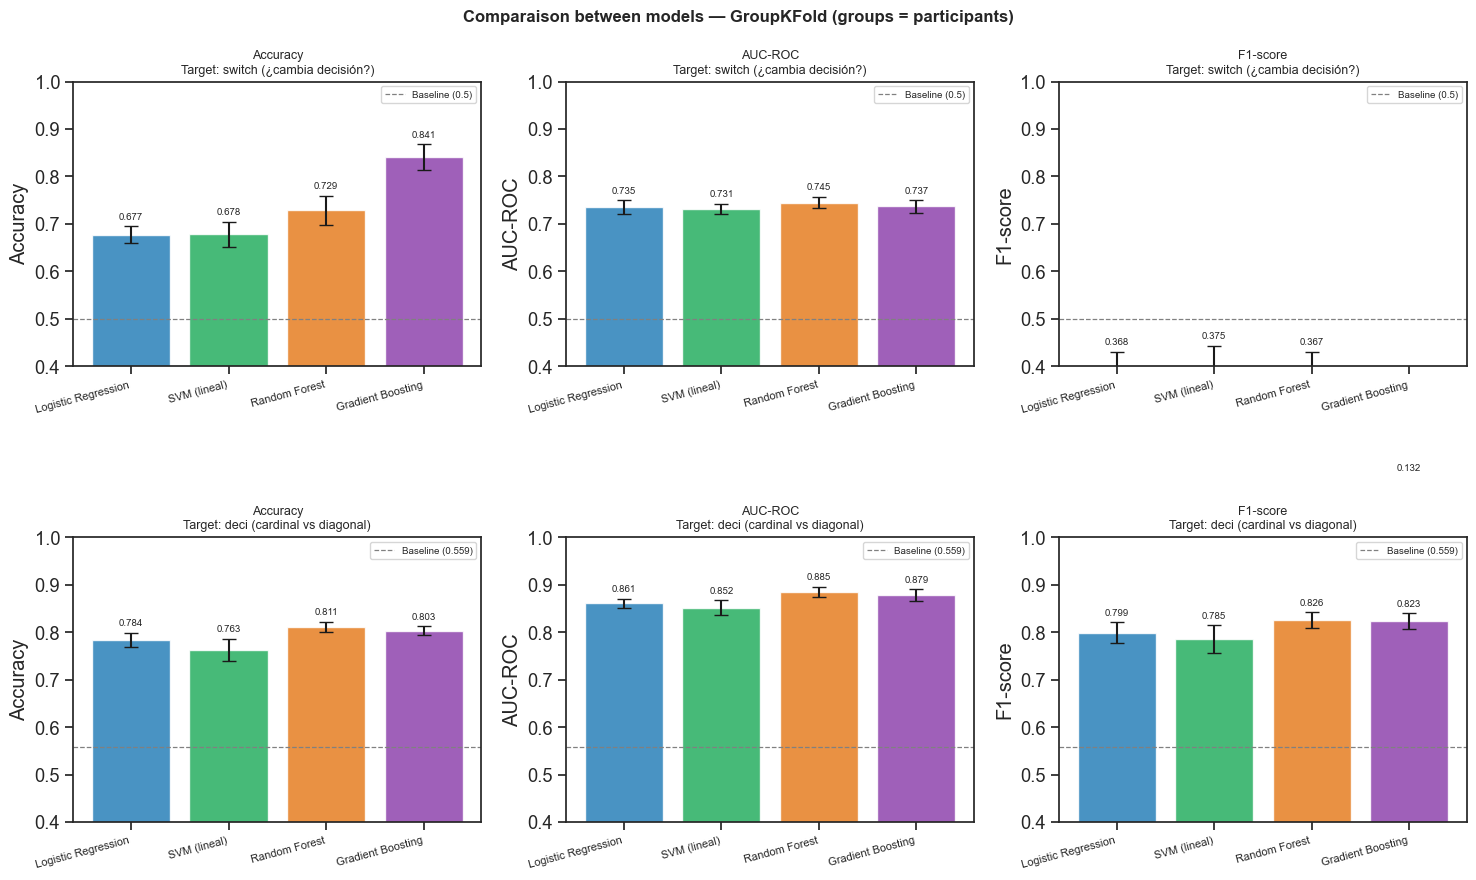

Figure saved: fig_model_comparison.png


In [80]:
# ── Celda 10: Figura comparativa de modelos ──────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
colors_m = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad']
names = list(models.keys())

for row_idx, (results, target_label, baseline) in enumerate([
    (results_sw, 'switch (¿cambia decisión?)',       0.5),
    (results_dc, 'deci (cardinal vs diagonal)', 0.559)
]):
    for col_idx, (metric_key, metric_label) in enumerate([
        ('acc_test', 'Accuracy'),
        ('auc_test', 'AUC-ROC'),
        ('f1_test',  'F1-score')
    ]):
        ax = axes[row_idx, col_idx]
        means = [results[m][metric_key].mean() for m in names]
        stds  = [results[m][metric_key].std()  for m in names]

        bars = ax.bar(names, means, yerr=stds, capsize=5,
                      color=colors_m, alpha=0.85)
        ax.axhline(baseline, color='gray', linestyle='--',
                   linewidth=0.9, label=f'Baseline ({baseline})')
        ax.set_title(f'{metric_label}\nTarget: {target_label}', fontsize=9)
        ax.set_ylabel(metric_label)
        ax.set_ylim(0.4, 1.0)
        ax.set_xticklabels(names, rotation=15, ha='right', fontsize=8)
        ax.legend(fontsize=7)
        for bar, mean, std in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width()/2,
                    mean + std + 0.01,
                    f'{mean:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Comparaison between models — GroupKFold (groups = participants)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_model_comparison.png')

---
## Bloque 4 — Ablación de features

Este análisis responde directamente a la **Hipótesis 5** del TFG: si las variables de historia de decisiones (CB) y metacognición aportan información por encima de la evidencia sensorial pura, el rendimiento debería aumentar progresivamente al añadirlas.

Los 4 conjuntos de features que comparamos:
1. **Solo sensorial** — solo evidencia del estímulo (rDV, d1–d6)
2. **Sensorial + Historia/CB** — awe add the previous decisionn and confidence
3. **Sensorial + Historia + Behavioural** — añadimos RT, nrep, trial_type
4. **Todas** — añadimos metacognición (metad_eff)

In [53]:
# ── Celda 11: Ablación de features ──────────────────────────────────────────

feature_sets = {
    '① Sensory\n(rDV, d1-d6)'             : sensory_features,
    '② + History/CB\n(deci-1, confi...)'   : sensory_features + history_features,
    '③ + Behavioural\n(RT, nrep...)'       : sensory_features + history_features + behav_features,
    '④ + Metacognition\n(metad_eff)'       : all_features
}

ablation_results = {}

for feat_label, feat_list in feature_sets.items():
    ablation_results[feat_label] = {}
    for target_label, (X_t, y_t, groups_t) in [
        ('switch', (X_sw, y_sw, groups_sw)),
        ('deci',   (X_dc, y_dc, groups_dc))
    ]:
        # Seleccionar solo las features disponibles en este conjunto
        feat_idx = [all_features.index(f) for f in feat_list if f in all_features]
        X_sub = X_t[:, feat_idx] if target_label == 'switch' else X_dc[:, feat_idx]

        # Modelo distinto según target (decisión basada en Bloque 3)
        # switch → Logistic Regression (sin overfitting, F1 y AUC honestos)
        # deci   → Random Forest (mejor AUC y accuracy)
        if target_label == 'switch':
            model_abl = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression(
                    class_weight='balanced', max_iter=1000, random_state=SEED
                ))
            ])
        else:
            model_abl = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', RandomForestClassifier(
                    n_estimators=300, max_depth=8, min_samples_leaf=20,
                    class_weight='balanced', random_state=SEED, n_jobs=-1
                ))
            ])

        groups_use = groups_sw if target_label == 'switch' else groups_dc
        cv = cross_validate(model_abl, X_sub, y_t, groups=groups_use,
                            cv=gkf, scoring=scoring, n_jobs=-1)

        ablation_results[feat_label][target_label] = {
            'acc'    : cv['test_accuracy'].mean(),
            'acc_std': cv['test_accuracy'].std(),
            'auc'    : cv['test_auc'].mean(),
            'auc_std': cv['test_auc'].std(),
        }

print('Ablation completed ✓')
for feat_label, res in ablation_results.items():
    print(f'\n{feat_label.replace(chr(10), " ")}')
    for tgt, vals in res.items():
        print(f'  {tgt:6s}: Acc={vals["acc"]:.3f}±{vals["acc_std"]:.3f}  AUC={vals["auc"]:.3f}±{vals["auc_std"]:.3f}')

Ablation completed ✓

① Sensory (rDV, d1-d6)
  switch: Acc=0.538±0.083  AUC=0.548±0.045
  deci  : Acc=0.724±0.013  AUC=0.803±0.011

② + History/CB (deci-1, confi...)
  switch: Acc=0.665±0.021  AUC=0.728±0.014
  deci  : Acc=0.804±0.012  AUC=0.878±0.010

③ + Behavioural (RT, nrep...)
  switch: Acc=0.685±0.021  AUC=0.742±0.014
  deci  : Acc=0.811±0.009  AUC=0.884±0.011

④ + Metacognition (metad_eff)
  switch: Acc=0.677±0.018  AUC=0.735±0.014
  deci  : Acc=0.811±0.011  AUC=0.885±0.011


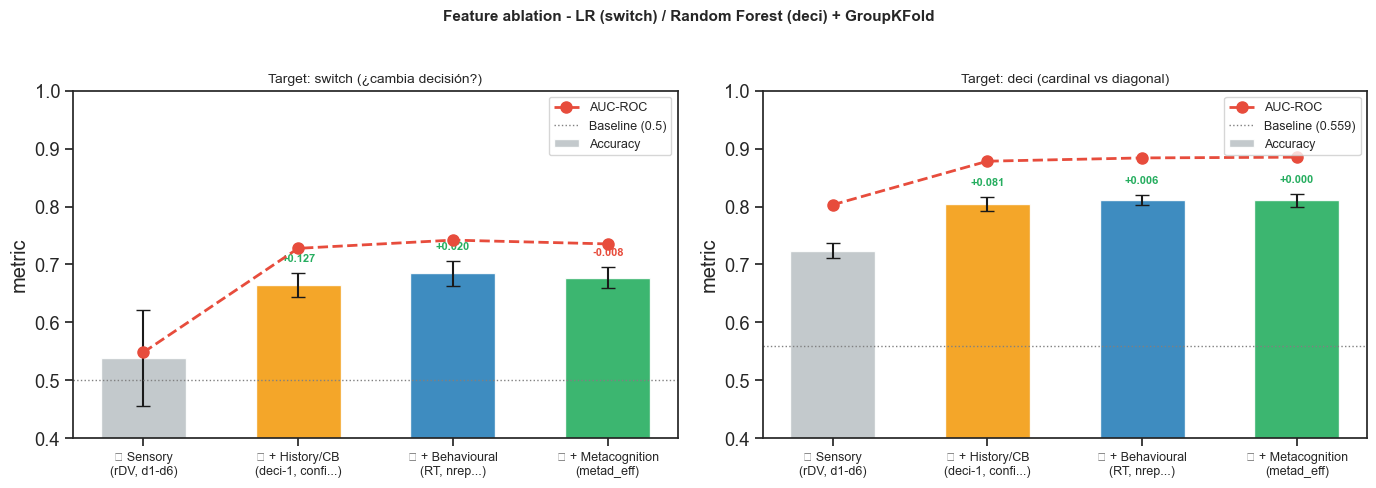

Figure saved: fig_ablation.png


In [65]:
# ── Celda 12: Figura ablación ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

set_labels = list(feature_sets.keys())
colors_abl = ['#bdc3c7', '#f39c12', '#2980b9', '#27ae60']

for ax, target_label, baseline, title in zip(
    axes,
    ['switch', 'deci'],
    [0.5, 0.559],
    ['Target: switch (¿cambia decisión?)', 'Target: deci (cardinal vs diagonal)']
):
    accs = [ablation_results[s][target_label]['acc'] for s in set_labels]
    stds = [ablation_results[s][target_label]['acc_std'] for s in set_labels]
    aucs = [ablation_results[s][target_label]['auc'] for s in set_labels]

    x = np.arange(len(set_labels))
    bars = ax.bar(x, accs, yerr=stds, capsize=5,
                  color=colors_abl, alpha=0.9, width=0.55, label='Accuracy')
    ax.plot(x, aucs, 'o--', color='#e74c3c', linewidth=2,
            markersize=8, label='AUC-ROC', zorder=5)
    ax.axhline(baseline, color='gray', linestyle=':', linewidth=1,
               label=f'Baseline ({baseline})')

    ax.set_xticks(x)
    ax.set_xticklabels(set_labels, fontsize=9)
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel('metric')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)

    # Anotaciones de gain
    for i in range(1, len(accs)):
        gain = accs[i] - accs[i-1]
        color = '#27ae60' if gain > 0 else '#e74c3c'
        ax.annotate(f'{gain:+.3f}',
                    xy=(i, accs[i] + stds[i] + 0.02),
                    ha='center', fontsize=8, color=color, fontweight='bold')

plt.suptitle('Feature ablation - LR (switch) / Random Forest (deci) + GroupKFold\n',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ablation.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_ablation.png')

---
## Bloque 5 — Variable importance (Permutation Importance)

Usamos **permutation importance** en lugar de la importancia de impureza de los árboles porque:
- Es válida para cualquier modelo, no solo árboles.
- No está sesgada hacia variables con muchos valores únicos.
- Mide el impacto real de cada variable: cuánto **empeora** el modelo cuando aleatorizamos esa variable.

In [55]:
# ── Celda 13: Permutation importance ────────────────────────────────────────
# Entrenamos sobre todos los datos y calculamos perm importance en el fold de
# test más grande (más estable estadísticamente). Se declara explícitamente
# que este modelo es SOLO para interpretación, no para estimar rendimiento.

def compute_perm_importance(X, y, groups, feature_names, n_repeats=50):
    """Calcula permutation importance usando un fold de GroupKFold."""
    gkf_pi = GroupKFold(n_splits=N_FOLDS)
    splits = list(gkf_pi.split(X, y, groups))

    # Elegimos el fold con más datos de test
    largest_fold = max(splits, key=lambda s: len(s[1]))
    train_idx, test_idx = largest_fold

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    gb = GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=3, subsample=0.8, random_state=SEED
    )
    gb.fit(X_tr_s, y_tr)

    perm = permutation_importance(
        gb, X_te_s, y_te,
        n_repeats=n_repeats,
        random_state=SEED,
        scoring='roc_auc',
        n_jobs=-1
    )

    return pd.DataFrame({
        'feature'  : feature_names,
        'imp_mean' : perm.importances_mean,
        'imp_std'  : perm.importances_std
    }).sort_values('imp_mean', ascending=False)

print('Calculando permutation importance para switch...')
perm_sw = compute_perm_importance(X_sw, y_sw, groups_sw, all_features)

print('Calculando permutation importance para deci...')
perm_dc = compute_perm_importance(X_dc, y_dc, groups_dc, all_features)

print('\nTop 8 variables — switch:')
print(perm_sw.head(8).round(4).to_string(index=False))
print('\nTop 8 variables — deci:')
print(perm_dc.head(8).round(4).to_string(index=False))

Calculando permutation importance para switch...
Calculando permutation importance para deci...

Top 8 variables — switch:
  feature  imp_mean  imp_std
   corr-1    0.0919   0.0134
 confi1_z    0.0847   0.0129
     RT_z    0.0279   0.0077
metad_eff    0.0172   0.0064
    rDV_z    0.0125   0.0047
       d6    0.0032   0.0033
       d1    0.0024   0.0041
       d3    0.0013   0.0022

Top 8 variables — deci:
 feature  imp_mean  imp_std
  deci-1    0.1430   0.0070
   rDV_z    0.1179   0.0095
    nrep    0.0191   0.0031
confi1_z    0.0089   0.0018
  deci-2    0.0045   0.0007
      d6    0.0039   0.0019
    RT_z    0.0032   0.0016
      d1    0.0016   0.0009


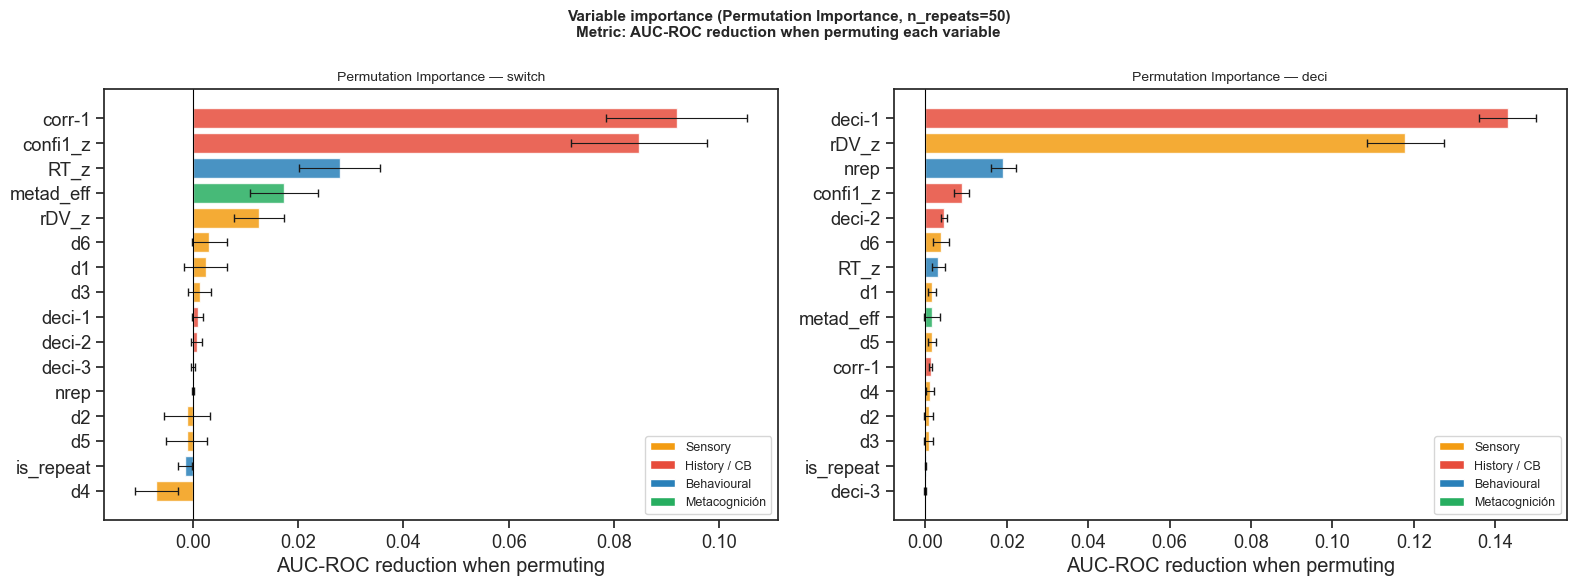

Figure saved: fig_permutation_importance.png


In [67]:
# ── Celda 14: Figura permutation importance ──────────────────────────────────

# Color por grupo de features
color_map = {}
for f in all_features:
    if f in sensory_features : color_map[f] = '#f39c12'
    elif f in history_features: color_map[f] = '#e74c3c'
    elif f in behav_features  : color_map[f] = '#2980b9'
    else                      : color_map[f] = '#27ae60'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, perm_df, title in zip(
    axes,
    [perm_sw, perm_dc],
    ['Permutation Importance — switch', 'Permutation Importance — deci']
):
    colors_pi = [color_map[f] for f in perm_df['feature']]
    ax.barh(perm_df['feature'], perm_df['imp_mean'],
            xerr=perm_df['imp_std'], color=colors_pi, alpha=0.85,
            capsize=3, error_kw={'linewidth': 0.8})
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('AUC-ROC reduction when permuting')
    ax.set_title(title, fontsize=10)
    ax.invert_yaxis()

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#f39c12', label='Sensory'),
        Patch(facecolor='#e74c3c', label='History / CB'),
        Patch(facecolor='#2980b9', label='Behavioural'),
        Patch(facecolor='#27ae60', label='Metacognición'),
    ]
    ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.suptitle('Variable importance (Permutation Importance, n_repeats=50)\n'
             'Metric: AUC-ROC reduction when permuting each variable',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_permutation_importance.png')

In [57]:
# ── Celda 15: Importancia agrupada por categoría ─────────────────────────────

groups_def = {
    'Sensory'    : sensory_features,
    'History / CB': history_features,
    'Behavioural'   : behav_features,
    'Metacognición': meta_features
}

print('Importancia agrupada por categoría de variable:\n')
for perm_df, target_label in [(perm_sw, 'switch'), (perm_dc, 'deci')]:
    print(f'── Target: {target_label} ──────────────────────────────────')
    group_imp = []
    for grp_name, feats in groups_def.items():
        mask = perm_df['feature'].isin(feats)
        total = perm_df[mask]['imp_mean'].sum()
        group_imp.append({'Grupo': grp_name, 'Importancia total': total})
    gi_df = pd.DataFrame(group_imp).sort_values('Importancia total', ascending=False)
    print(gi_df.round(4).to_string(index=False))
    print()

Importancia agrupada por categoría de variable:

── Target: switch ──────────────────────────────────
        Grupo  Importancia total
 History / CB             0.1783
  Behavioural             0.0264
Metacognición             0.0172
      Sensory             0.0102

── Target: deci ──────────────────────────────────
        Grupo  Importancia total
 History / CB             0.1577
      Sensory             0.1278
  Behavioural             0.0224
Metacognición             0.0016



---
## Bloque 6 — Análisis por nrep

Si la historia de decisiones es lo que hace predecible el comportamiento, el modelo debería rendir **mejor en nrep=2 que en nrep=1**, porque en nrep=2 hay más historia disponible (dos decisiones decisions). En nrep=0 no hay historia, por lo que el rendimiento debería ser el más bajo (especialmente para `switch`).

In [58]:
# ── Celda 16: Rendimiento por nrep ──────────────────────────────────────────

results_nrep = {}

for nrep_val in [0, 1, 2]:
    results_nrep[nrep_val] = {}
    for target_col, df_t, feat_list in [
        ('deci',   df_deci, all_features),       # deci: todos los nrep
    ]:
        mask = df_t['nrep'] == nrep_val
        sub  = df_t[mask].dropna(subset=feat_list + [target_col, 'subj'])
        if sub['subj'].nunique() < N_FOLDS:
            print(f'nrep={nrep_val}, {target_col}: pocos participants, saltando.')
            continue

        X_sub = sub[feat_list].values
        y_sub = sub[target_col].values
        g_sub = sub['subj'].values

        gb_sub = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', GradientBoostingClassifier(
                n_estimators=300, learning_rate=0.05,
                max_depth=3, subsample=0.8, random_state=SEED
            ))
        ])
        cv = cross_validate(gb_sub, X_sub, y_sub, groups=g_sub,
                            cv=GroupKFold(n_splits=min(N_FOLDS, sub['subj'].nunique())),
                            scoring=scoring, n_jobs=-1)
        results_nrep[nrep_val][target_col] = {
            'acc': cv['test_accuracy'],
            'auc': cv['test_auc'],
            'n'  : len(sub)
        }
        print(f'nrep={nrep_val}, {target_col} (n={len(sub)}): '
              f'Acc={cv["test_accuracy"].mean():.3f}  AUC={cv["test_auc"].mean():.3f}')

# Para switch: solo nrep 1 y 2 (necesita decisión prev. decision)
for nrep_val in [1, 2]:
    mask = df_switch['nrep'] == nrep_val
    sub  = df_switch[mask].dropna(subset=all_features + ['switch', 'subj'])
    if sub['subj'].nunique() < N_FOLDS:
        continue
    X_sub = sub[all_features].values
    y_sub = sub['switch'].values
    g_sub = sub['subj'].values
    gb_sub = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05,
            max_depth=3, subsample=0.8, random_state=SEED
        ))
    ])
    cv = cross_validate(gb_sub, X_sub, y_sub, groups=g_sub,
                        cv=GroupKFold(n_splits=min(N_FOLDS, sub['subj'].nunique())),
                        scoring=scoring, n_jobs=-1)
    if 'switch' not in results_nrep[nrep_val]:
        results_nrep[nrep_val]['switch'] = {}
    results_nrep[nrep_val]['switch'] = {
        'acc': cv['test_accuracy'],
        'auc': cv['test_auc'],
        'n'  : len(sub)
    }
    print(f'nrep={nrep_val}, switch  (n={len(sub)}): '
          f'Acc={cv["test_accuracy"].mean():.3f}  AUC={cv["test_auc"].mean():.3f}')

nrep=0, deci (n=2079): Acc=0.709  AUC=0.786
nrep=1, deci (n=2100): Acc=0.832  AUC=0.894
nrep=2, deci (n=2095): Acc=0.862  AUC=0.920
nrep=1, switch  (n=2100): Acc=0.841  AUC=0.714
nrep=2, switch  (n=2095): Acc=0.848  AUC=0.697


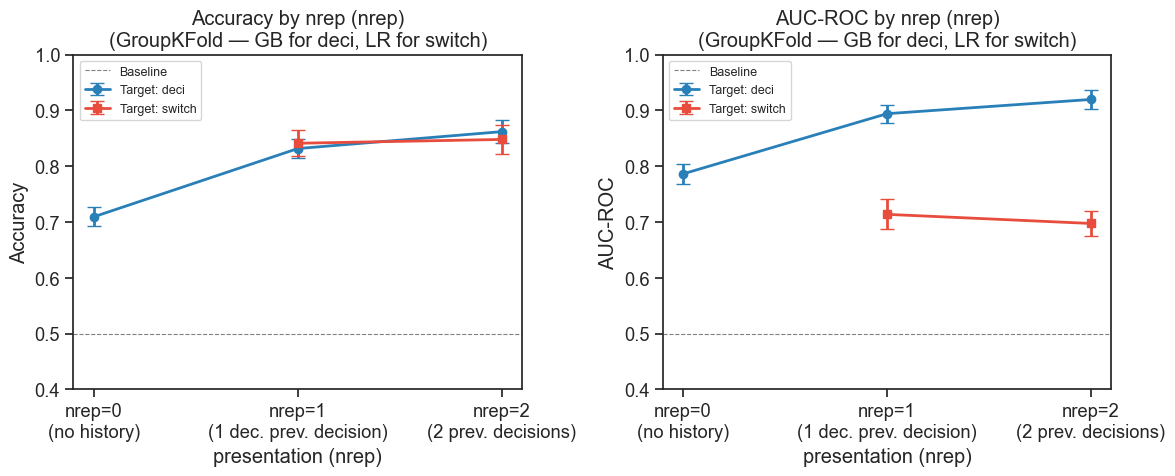

Figure saved: fig_performance_by_nrep.png


In [69]:
# ── Celda 17: Figura por nrep ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, ylabel in [(axes[0], 'acc', 'Accuracy'), (axes[1], 'auc', 'AUC-ROC')]:
    for target_col, color, marker, label in [
        ('deci',   '#2980b9', 'o', 'deci'),
        ('switch', '#e74c3c', 's', 'switch')
    ]:
        nrep_vals, means, stds = [], [], []
        for nrep_val in [0, 1, 2]:
            if nrep_val in results_nrep and target_col in results_nrep[nrep_val]:
                nrep_vals.append(nrep_val)
                means.append(results_nrep[nrep_val][target_col][metric].mean())
                stds.append(results_nrep[nrep_val][target_col][metric].std())
        ax.errorbar(nrep_vals, means, yerr=stds,
                    marker=marker, color=color, linewidth=2,
                    capsize=5, label=f'Target: {label}')

    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Baseline')
    ax.set_xlabel('presentation (nrep)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} by nrep (nrep)\n(GroupKFold — GB for deci, LR for switch)')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['nrep=0\n(no history)', 'nrep=1\n(1 dec. prev. decision)', 'nrep=2\n(2 prev. decisions)'])
    ax.legend(fontsize=9)
    ax.set_ylim(0.4, 1.0)

plt.tight_layout()
plt.savefig('fig_performance_by_nrep.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_performance_by_nrep.png')

---
## Bloque 7 — Diferencias individuales

¿Hay participants más predecibles que otros? Si el CB es lo que hace predecible el comportamiento, los participants con mayor CB deberían tener mayor accuracy individual. Esto conecta directamente con las diferencias individuales observadas en el análisis conductual.

In [71]:
# ── Celda 18: Accuracy por participant (Leave-One-Subject-Out) ──────────────
# Para las diferencias individuales usamos LOSO: entrenamos en todos menos uno
# y testamos en ese uno. Así obtenemos una estimación por participant.

loso = LeaveOneGroupOut()

def accuracy_per_subject(X, y, groups, feature_names):
    """Devuelve accuracy por participant usando LOSO."""
    subj_acc = {}
    subj_auc = {}
    unique_subjs = np.unique(groups)

    gb = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05,
            max_depth=3, subsample=0.8, random_state=SEED
        ))
    ])

    for train_idx, test_idx in loso.split(X, y, groups):
        subj_id = str(groups[test_idx[0]])
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        if len(np.unique(y_te)) < 2:
            continue

        gb.fit(X_tr, y_tr)
        acc = (gb.predict(X_te) == y_te).mean()
        try:
            auc = roc_auc_score(y_te, gb.predict_proba(X_te)[:, 1])
        except:
            auc = np.nan

        subj_acc[subj_id] = acc
        subj_auc[subj_id] = auc

    return pd.DataFrame({
        'subj'    : list(subj_acc.keys()),
        'accuracy': list(subj_acc.values()),
        'auc'     : list(subj_auc.values())
    }).sort_values('accuracy', ascending=False).reset_index(drop=True)

print('Calculando accuracy por participant (LOSO) — switch...')
subj_sw = accuracy_per_subject(X_sw, y_sw, groups_sw, all_features)

print('Calculando accuracy por participant (LOSO) — deci...')
subj_dc = accuracy_per_subject(X_dc, y_dc, groups_dc, all_features)

print(f'\nSwitch — Media: {subj_sw.accuracy.mean():.3f}  SD: {subj_sw.accuracy.std():.3f}')
print(f'Deci   — Media: {subj_dc.accuracy.mean():.3f}  SD: {subj_dc.accuracy.std():.3f}')

Calculando accuracy por participant (LOSO) — switch...
Calculando accuracy por participant (LOSO) — deci...

Switch — Media: 0.850  SD: 0.074
Deci   — Media: 0.810  SD: 0.046


In [75]:
# ── Celda 19: Correlación accuracy individual vs métricas conductuales de CB ─

# Usamos npar como clave (igual que subj_sw y subj_dc)
subj_metrics = df_switch.groupby('npar').agg(
    p_repeat   = ('switch',    lambda x: 1 - x.mean()),
    metad_eff  = ('metad_eff', 'first'),
    mean_confi = ('confi',     'mean')
).reset_index()

subj_metrics['cb_index'] = subj_metrics['p_repeat']

# Convertimos todo a string para el merge
subj_metrics['npar'] = subj_metrics['npar'].astype(str)
subj_sw['subj']      = subj_sw['subj'].astype(str)
subj_dc['subj']      = subj_dc['subj'].astype(str)

# Merge usando npar como clave común
merged_sw = subj_sw.merge(subj_metrics, left_on='subj', right_on='npar', how='inner')
merged_dc = subj_dc.merge(subj_metrics, left_on='subj', right_on='npar', how='inner')

print(f'merged_sw filas: {len(merged_sw)}')
print(f'merged_dc filas: {len(merged_dc)}')

print('Correlaciones: Accuracy individual ~ Métricas conductuales')

print('\n── Target: switch ──────────────────────────────────────────')
for col, label in [
    ('p_repeat',   'p(maintain decision)'),
    ('metad_eff',  'Metacognitive efficiency'),
    ('mean_confi', 'Mean confidence')
]:
    if col in merged_sw.columns:
        tmp = merged_sw[['accuracy', col]].dropna()  # dropna sobre las dos columnas juntas
        if len(tmp) < 2:
            print(f'  {label:30s}: not enough data')
            continue
        r, p = stats.pearsonr(tmp['accuracy'], tmp[col])
        sig = '✓ sig.' if p < 0.05 else 'n.s.'
        print(f'  {label:30s}: r={r:+.3f}, p={p:.4f} {sig}')

print('\n── Target: deci ────────────────────────────────────────────')
for col, label in [
    ('p_repeat',   'p(maintain decision)'),
    ('metad_eff',  'Metacognitive efficiency'),
    ('mean_confi', 'Mean confidence')
]:
    if col in merged_dc.columns:
        tmp = merged_dc[['accuracy', col]].dropna()  # dropna sobre las dos columnas juntas
        if len(tmp) < 2:
            print(f'  {label:30s}: not enough data')
            continue
        r, p = stats.pearsonr(tmp['accuracy'], tmp[col])
        sig = '✓ sig.' if p < 0.05 else 'n.s.'
        print(f'  {label:30s}: r={r:+.3f}, p={p:.4f} {sig}')

merged_sw filas: 24
merged_dc filas: 24
Correlaciones: Accuracy individual ~ Métricas conductuales

── Target: switch ──────────────────────────────────────────
  p(maintain decision)          : r=+0.984, p=0.0000 ✓ sig.
  Metacognitive efficiency      : r=+0.122, p=0.5715 n.s.
  Mean confidence               : r=+0.231, p=0.2773 n.s.

── Target: deci ────────────────────────────────────────────
  p(maintain decision)          : r=+0.875, p=0.0000 ✓ sig.
  Metacognitive efficiency      : r=+0.073, p=0.7329 n.s.
  Mean confidence               : r=+0.269, p=0.2039 n.s.


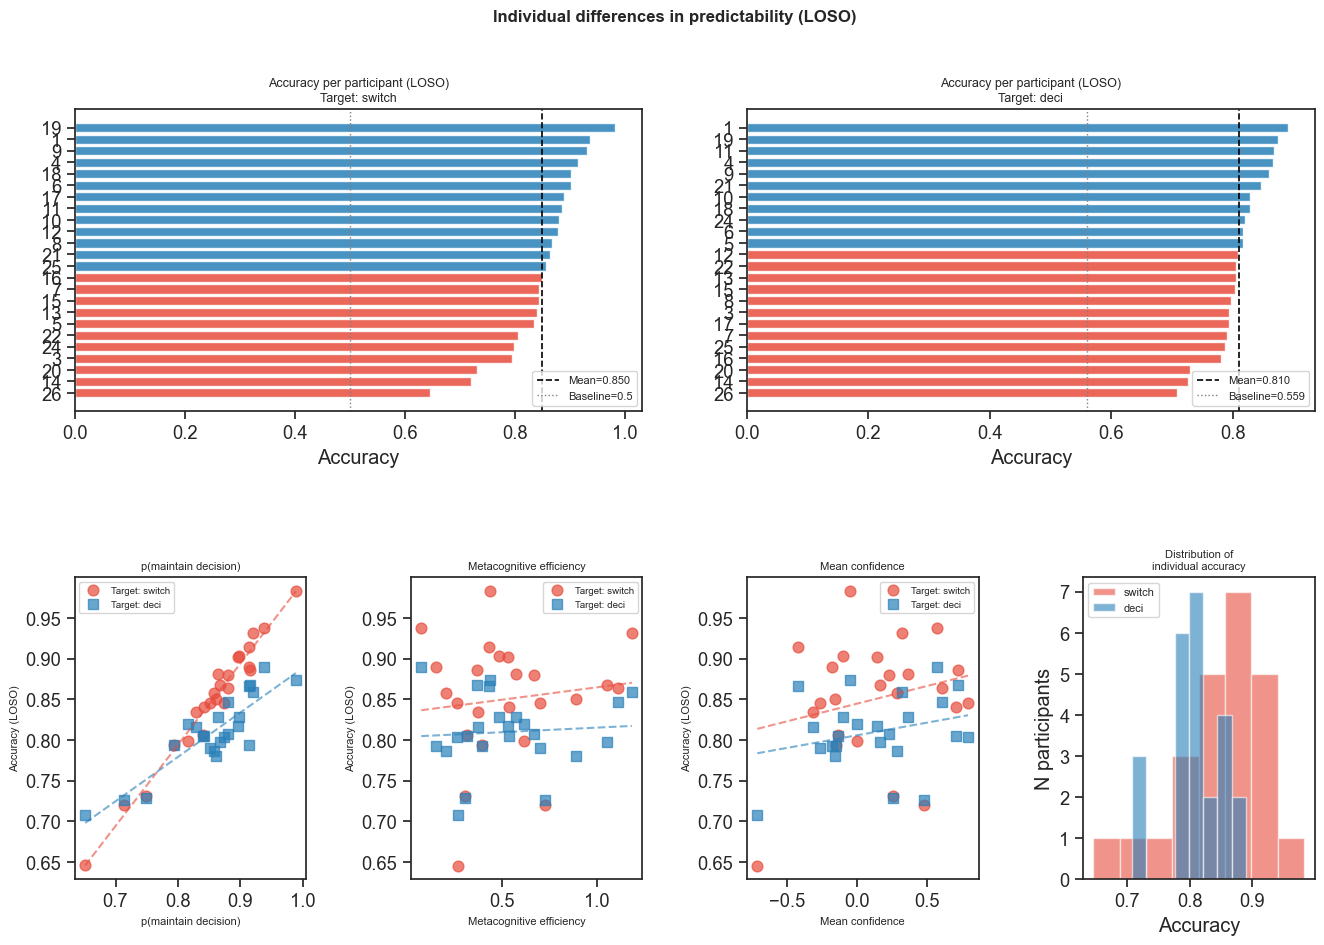

Figure saved: fig_individual_differences.png


In [77]:
# ── Celda 20: Figura diferencias individuales ────────────────────────────────

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 4, wspace=0.45, hspace=0.55)

# ── Fila 0: accuracy por participant ────────────────────────────────────────
for col_idx, (subj_df_plot, target_label, baseline) in enumerate([
    (subj_sw, 'switch', 0.5),
    (subj_dc, 'deci',   0.559)
]):
    ax = fig.add_subplot(gs[0, col_idx*2:col_idx*2+2])
    colors_subj = ['#2980b9' if a >= subj_df_plot.accuracy.mean()
                   else '#e74c3c' for a in subj_df_plot.accuracy]
    ax.barh(subj_df_plot['subj'].astype(str), subj_df_plot['accuracy'],
            color=colors_subj, alpha=0.85)
    ax.axvline(subj_df_plot.accuracy.mean(), color='black', linestyle='--',
               linewidth=1.2, label=f'Mean={subj_df_plot.accuracy.mean():.3f}')
    ax.axvline(baseline, color='gray', linestyle=':', linewidth=1,
               label=f'Baseline={baseline}')
    ax.set_xlabel('Accuracy')
    ax.set_title(f'Accuracy per participant (LOSO)\nTarget: {target_label}', fontsize=9)
    ax.legend(fontsize=8)
    ax.invert_yaxis()

# ── Fila 1: scatters accuracy vs métricas CB ─────────────────────────────────
for col_idx, (col, xlabel) in enumerate([
    ('p_repeat',   'p(maintain decision)'),
    ('metad_eff',  'Metacognitive efficiency'),
    ('mean_confi', 'Mean confidence'),
]):
    if col_idx >= 4:
        break
    ax = fig.add_subplot(gs[1, col_idx])
    for merged, color, marker, label in [
        (merged_sw, '#e74c3c', 'o', 'switch'),
        (merged_dc, '#2980b9', 's', 'deci')
    ]:
        if col not in merged.columns:
            continue
        x = merged[col].dropna()
        y_plot = merged.loc[x.index, 'accuracy']
        ax.scatter(x, y_plot, color=color, marker=marker,
                   alpha=0.7, s=60, label=f'Target: {label}')
        # Línea de regresión
        if len(x) > 3:
            m, b, r, p, _ = stats.linregress(x, y_plot)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, m*x_line + b, color=color,
                    linewidth=1.5, linestyle='--', alpha=0.6)
            sig = '*' if p < 0.05 else ''
            ax.set_title(xlabel, fontsize=8)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel('Accuracy (LOSO)', fontsize=8)
    ax.legend(fontsize=7)

# 4º scatter: distribución de accuracies
ax4 = fig.add_subplot(gs[1, 3])
ax4.hist(subj_sw.accuracy, bins=8, alpha=0.6, color='#e74c3c', label='switch', edgecolor='white')
ax4.hist(subj_dc.accuracy, bins=8, alpha=0.6, color='#2980b9', label='deci',   edgecolor='white')
ax4.set_xlabel('Accuracy')
ax4.set_ylabel('N participants')
ax4.set_title('Distribution of\nindividual accuracy', fontsize=8)
ax4.legend(fontsize=8)

plt.suptitle('Individual differences in predictability (LOSO)',
             fontsize=12, fontweight='bold')
plt.savefig('fig_individual_differences.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: fig_individual_differences.png')

---
## Bloque 8 — Resumen final y tabla de resultados

In [ ]:
# ── Celda 21: Tabla resumen completa para el informe ────────────────────────

print('=' * 70)
print('RESUMEN FINAL — ANÁLISIS DE MACHINE LEARNING')
print('=' * 70)

print('\n── Validación: GroupKFold (k=5, groups = participants) ─────────────')
print('   Todos los resultados de rendimiento son generalización a nuevos sujetos')

print('\n── TARGET 1: switch (¿cambia la decisión?) ──────────────────────────')
for name, res in results_sw.items():
    print(f'  {name:22s}  Acc={res["acc_test"].mean():.3f}±{res["acc_test"].std():.3f}'
          f'  AUC={res["auc_test"].mean():.3f}±{res["auc_test"].std():.3f}'
          f'  F1={res["f1_test"].mean():.3f}')

print('\n── TARGET 2: deci (cardinal vs diagonal) ────────────────────────────')
for name, res in results_dc.items():
    print(f'  {name:22s}  Acc={res["acc_test"].mean():.3f}±{res["acc_test"].std():.3f}'
          f'  AUC={res["auc_test"].mean():.3f}±{res["auc_test"].std():.3f}'
          f'  F1={res["f1_test"].mean():.3f}')

print('\n── Ablación de features (LR para switch / RF para deci) ─────────────')
for feat_label, res in ablation_results.items():
    label_clean = feat_label.replace('\n', ' ')
    if 'switch' in res:
        print(f'  {label_clean:45s}  Acc={res["switch"]["acc"]:.3f}  AUC={res["switch"]["auc"]:.3f}')

print('\n── Top 5 variables — switch (Permutation Importance, AUC) ──────────')
for _, row in perm_sw.head(5).iterrows():
    print(f'  {row["feature"]:12s}: {row["imp_mean"]:+.4f} ± {row["imp_std"]:.4f}')

print('\n── Diferencias individuales (LOSO) ──────────────────────────────────')
print(f'  Switch — Acc media: {subj_sw.accuracy.mean():.3f}  SD: {subj_sw.accuracy.std():.3f}')
print(f'  Deci   — Acc media: {subj_dc.accuracy.mean():.3f}  SD: {subj_dc.accuracy.std():.3f}')

RESUMEN FINAL — ANÁLISIS DE MACHINE LEARNING

── Validación: GroupKFold (k=5, groups = participants) ─────────────
   Todos los resultados de rendimiento son generalización a nuevos sujetos

── TARGET 1: switch (¿cambia la decisión?) ──────────────────────────
  Logistic Regression     Acc=0.677±0.018  AUC=0.735±0.014  F1=0.368
  SVM (lineal)            Acc=0.678±0.027  AUC=0.731±0.011  F1=0.375
  Random Forest           Acc=0.729±0.030  AUC=0.745±0.012  F1=0.367
  Gradient Boosting       Acc=0.841±0.027  AUC=0.737±0.013  F1=0.132

── TARGET 2: deci (cardinal vs diagonal) ────────────────────────────
  Logistic Regression     Acc=0.784±0.015  AUC=0.861±0.010  F1=0.799
  SVM (lineal)            Acc=0.763±0.024  AUC=0.852±0.015  F1=0.785
  Random Forest           Acc=0.811±0.011  AUC=0.885±0.011  F1=0.826
  Gradient Boosting       Acc=0.803±0.009  AUC=0.879±0.013  F1=0.823

── Ablación de features (Gradient Boosting, target: switch) ─────────
  ① Sensory (rDV, d1-d6)                     

In [79]:
# ── Celda 22: Guardar resultados en CSV ──────────────────────────────────────

import os
os.makedirs('ml_results', exist_ok=True)

# Rendimiento de modelos
rows_sw, rows_dc = [], []
for name, res in results_sw.items():
    rows_sw.append({'modelo': name, 'target': 'switch',
                    'acc_mean': res['acc_test'].mean(), 'acc_std': res['acc_test'].std(),
                    'auc_mean': res['auc_test'].mean(), 'auc_std': res['auc_test'].std(),
                    'f1_mean' : res['f1_test'].mean()})
for name, res in results_dc.items():
    rows_dc.append({'modelo': name, 'target': 'deci',
                    'acc_mean': res['acc_test'].mean(), 'acc_std': res['acc_test'].std(),
                    'auc_mean': res['auc_test'].mean(), 'auc_std': res['auc_test'].std(),
                    'f1_mean' : res['f1_test'].mean()})

pd.DataFrame(rows_sw + rows_dc).round(4).to_csv('ml_results/model_performance.csv', index=False)
perm_sw.round(4).to_csv('ml_results/perm_importance_switch.csv', index=False)
perm_dc.round(4).to_csv('ml_results/perm_importance_deci.csv', index=False)
subj_sw.round(4).to_csv('ml_results/subject_accuracy_switch.csv', index=False)
subj_dc.round(4).to_csv('ml_results/subject_accuracy_deci.csv', index=False)

print('Resultados guardados en ml_results/ ✓')
print('  - model_performance.csv')
print('  - perm_importance_switch.csv')
print('  - perm_importance_deci.csv')
print('  - subject_accuracy_switch.csv')
print('  - subject_accuracy_deci.csv')

Resultados guardados en ml_results/ ✓
  - model_performance.csv
  - perm_importance_switch.csv
  - perm_importance_deci.csv
  - subject_accuracy_switch.csv
  - subject_accuracy_deci.csv
